In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import PyMieScatt as ps
import pymiediff as pmd
import time
# Reproducibility — same "random" numbers every run
np.random.seed(42)
torch.manual_seed(42)

homogeneous particle (on device: cpu)
 - layers   = 1
 - radii    = tensor([400.])nm
 - materials: ['eps=1.56+i3.200']
 - environment    : eps=1.00

tensor([274.5058, 273.7871, 271.6404, 268.0966, 263.2036, 257.0287, 249.6560,
        241.1846, 231.7265, 221.4044, 210.3505, 198.7021, 186.6005, 174.1874,
        161.6032, 148.9846, 136.4612, 124.1548, 112.1774, 100.6294,  89.5983,
         79.1584,  69.3701,  60.2794,  51.9181,  44.3049,  37.4451,  31.3323,
         25.9488,  21.2676,  17.2529,  13.8626,  11.0488,   8.7599,   6.9419,
          5.5395,   4.4976,   3.7625,   3.2825,   3.0094,   2.8983,   2.9088,
          3.0051,   3.1561,   3.3355,   3.5217,   3.6978,   3.8510,   3.9723,
          4.0563,   4.1005,   4.1048,   4.0712,   4.0032,   3.9055,   3.7834,
          3.6426,   3.4886,   3.3269,   3.1624,   2.9995,   2.8418,   2.6923,
          2.5529,   2.4253,   2.3099,   2.2070,   2.1160,   2.0363,   1.9665,
          1.9055,   1.8517,   1.8037,   1.7601,   1.7197,   1.6815,   1

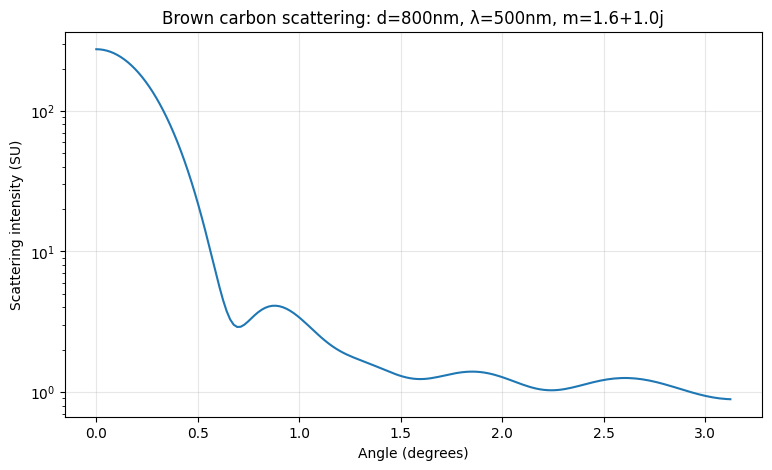

In [9]:

def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    print(p)
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    print(angle_scattering["i_unpol"])
    
    return angle_scattering['i_unpol']

# Brown carbon at the center of our range
n = 1.6
k = 1.0
wavelength = 500   # nm
diameter = 800     # nm
theta = torch.arange(0, 181) * torch.pi/181

scattering = py_Mie_Diff_Scattering(wavelength, diameter, n, k)

plt.figure(figsize=(9, 5))
plt.plot(theta, scattering)
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity (SU)")
plt.title(f"Brown carbon scattering: d={diameter}nm, λ={wavelength}nm, m=1.6+1.0j")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

Generating 500 particles via pyMieDiff (with derivatives)...
  particle 0/500
  particle 50/500
  particle 100/500
  particle 150/500
  particle 200/500
  particle 250/500
  particle 300/500
  particle 350/500
  particle 400/500
  particle 450/500


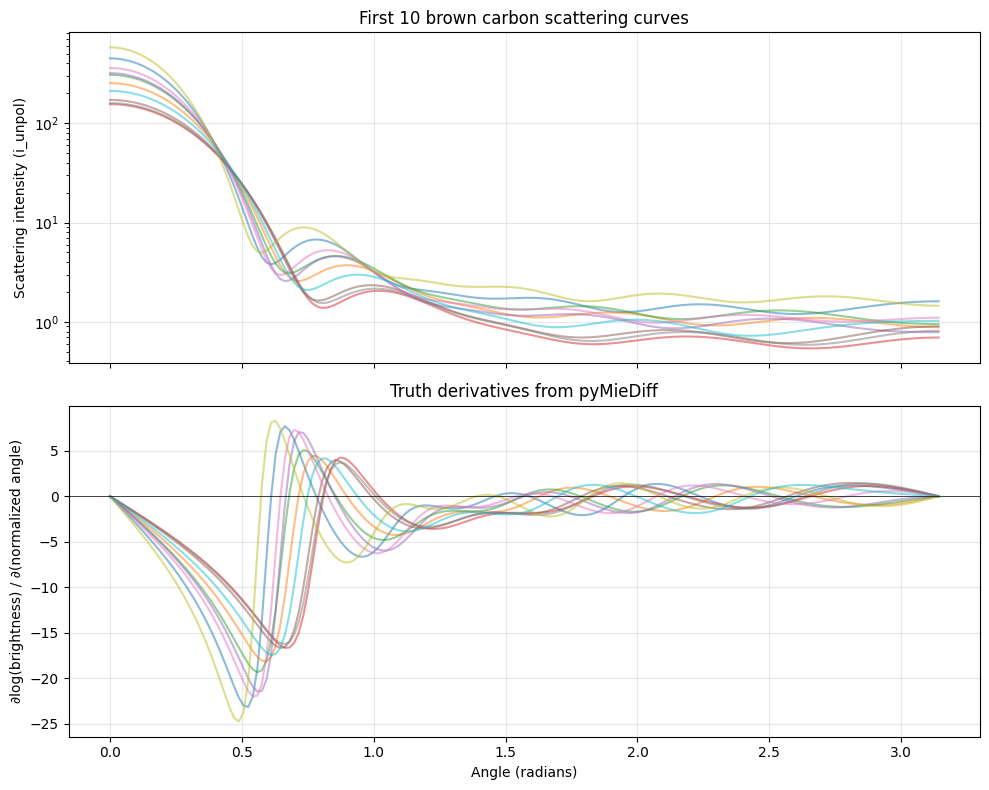


Done generating!
particle_inputs shape: (500, 181, 5)
particle_outputs shape: (500, 181)
particle_derivatives shape: (500, 181)


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pymiediff as pmd

N_PARTICLES = 500
N_ANGLES = 181

# Particle-level storage: shape (N_PARTICLES, N_ANGLES, ...)
particle_inputs = np.zeros((N_PARTICLES, N_ANGLES, 5))
particle_outputs = np.zeros((N_PARTICLES, N_ANGLES))
particle_derivatives = np.zeros((N_PARTICLES, N_ANGLES))

print(f"Generating {N_PARTICLES} particles via pyMieDiff (with derivatives)...")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for p in range(N_PARTICLES):
    # Sample random particle parameters
    wavelength = np.random.uniform(450, 550)
    diameter   = np.random.uniform(700, 900)
    n          = np.random.uniform(1.5, 1.86)
    k          = np.random.uniform(0.68, 1.00)
    
    # Setup pyMieDiff with autograd
    theta_norm = torch.linspace(0, 1, N_ANGLES, requires_grad=True)
    theta_rad = theta_norm * torch.pi
    
    particle = pmd.Particle(
        r_layers=[diameter / 2],
        mat_layers=[complex(n, k)],
        mat_env=1.00
    )

    k0 = 2 * torch.pi / torch.tensor([float(wavelength)])
    
    scattering = particle.get_angular_scattering(k0=k0, theta=theta_rad)
    unpol_scattering = scattering['i_unpol']
    log_scat = torch.log10(unpol_scattering)
    
    # Truth derivative — one autograd call gives all 181 derivatives
    derivative_wrt_angle = torch.autograd.grad(log_scat.sum(), theta_norm)[0]
    
    # Store this particle's 181 angles in one shot (NumPy broadcasting)
    particle_inputs[p, :, 0] = n    # for current particle, store n
    particle_inputs[p, :, 1] = k    # store k
    particle_inputs[p, :, 2] = wavelength   # store wavelength
    particle_inputs[p, :, 3] = diameter     # store diameter
    particle_inputs[p, :, 4] = theta_rad.detach().numpy()   # store individual angles in each angle entry
    
    particle_outputs[p, :] = unpol_scattering.detach().numpy()
    particle_derivatives[p, :] = derivative_wrt_angle.detach().numpy()
    
    # Plot a few particles for visualization
    if p < 10:
        axes[0].plot(theta_rad.detach().numpy(), unpol_scattering.detach().numpy(), alpha=0.5)
        axes[1].plot(theta_rad.detach().numpy(), derivative_wrt_angle.detach().numpy(), alpha=0.5)
    
    if p % 50 == 0:
        print(f"  particle {p}/{N_PARTICLES}")

axes[0].set_ylabel('Scattering intensity (i_unpol)')
axes[0].set_title('First 10 brown carbon scattering curves')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Angle (radians)')
axes[1].set_ylabel('∂log(brightness) / ∂(normalized angle)')
axes[1].set_title('Truth derivatives from pyMieDiff')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\nDone generating!")
print(f"particle_inputs shape: {particle_inputs.shape}")
print(f"particle_outputs shape: {particle_outputs.shape}")
print(f"particle_derivatives shape: {particle_derivatives.shape}")

In [11]:
# flatten particle data for training
inputs = particle_inputs.reshape(-1, 5) # each entry should have each of the 5 params
outputs = particle_outputs.reshape(-1, 1)
derivatives = particle_derivatives.reshape(-1, 1)

N_SAMPLES = inputs.shape[0] # num of rows in inputs

# log transform the outputs
log_outputs = np.log10(outputs)

# normalize the inputs to roughly [0, 1]
# wavelength: 450-550 → (wavelength - 450) / 100
# diameter:   700-900 → (diameter - 700) / 200
inputs_norm = np.zeros_like(inputs)
inputs_norm[:, 0] = (inputs[:, 0] - 1.5) / (1.86 - 1.5)        # n
inputs_norm[:, 1] = (inputs[:, 1] - 0.68) / (1.00 - 0.68)      # k
inputs_norm[:, 2] = (inputs[:, 2] - 450) / 100                  # wavelength
inputs_norm[:, 3] = (inputs[:, 3] - 700) / 200                  # diameter
inputs_norm[:, 4] = inputs[:, 4] / np.pi

# train/test split 80 percent train, 20 percent test
n_train = int(0.8 * N_SAMPLES)
X_train = torch.FloatTensor(inputs_norm[:n_train])
y_train = torch.FloatTensor(log_outputs[:n_train])
dy_train = torch.FloatTensor(derivatives[:n_train]) # used in Loss Function only

X_test = torch.FloatTensor(inputs_norm[n_train:])
y_test = torch.FloatTensor(log_outputs[n_train:])
dy_test = torch.FloatTensor(derivatives[n_train:])

print(f"Shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}, dy_train: {dy_train.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}, dy_test:  {dy_test.shape}")
print()
print(f"Sample input (normalized): {X_train[0]}")
print(f"Sample output (log): {y_train[0]}")
print(f"Sample derivative (truth): {dy_train[0]}")

Shapes:
  X_train: torch.Size([72400, 5]), y_train: torch.Size([72400, 1]), dy_train: torch.Size([72400, 1])
  X_test:  torch.Size([18100, 5]), y_test:  torch.Size([18100, 1]), dy_test:  torch.Size([18100, 1])

Sample input (normalized): tensor([0.7320, 0.5987, 0.3745, 0.9507, 0.0000])
Sample output (log): tensor([2.6517])
Sample derivative (truth): tensor([-0.])


In [12]:
model = nn.Sequential(
    nn.Linear(5, 128),       # input layer: 4 features to 128 neurons
    nn.GELU(),
    nn.Linear(128, 256),     # hidden layer: 128 to 256
    nn.GELU(),
    nn.Linear(256, 128),    # output layer: 256 to 256 (one per angle)
    nn.GELU(),
    nn.Linear(128,1)
    
)

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Sequential(
  (0): Linear(in_features=5, out_features=128, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=128, out_features=256, bias=True)
  (3): GELU(approximate='none')
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): GELU(approximate='none')
  (6): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 66817


In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = nn.MSELoss()

print("Optimizer:", optimizer)
print("Loss function:", loss_fn)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


In [ ]:
N_EPOCHS = 100
BATCH_SIZE = 128

train_losses = []
test_losses = []

n_train = X_train.shape[0]
n_batches = n_train // BATCH_SIZE
derivative_normalization = 0.01

# def determine_derivative()
print(f"Training: {N_EPOCHS} epochs, {n_batches} batches per epoch\n")

training_start = time.time()

for epoch in range(N_EPOCHS):
    # Shuffle training data each epoch
    perm = torch.randperm(n_train)# generates a random permutation of the numbers up to 800
    X_shuffled = X_train[perm] # shuffle the training data according to the permutation
    y_shuffled = y_train[perm] # shuffle the 'answers' for the training data
    dy_shuffled = dy_train[perm] # shuffle the derivatives the same way

    # Train one epoch (one pass through the data, in mini-batches)
    epoch_loss = 0.0

    for i in range(n_batches):
        start = i * BATCH_SIZE # index work to see where batch starts
        end = start + BATCH_SIZE # index work to see where each batch ends while looping through the batches
        X_batch = X_shuffled[start:end].requires_grad_(True) # diameters and wavelengths used in this batch
        y_batch = y_shuffled[start:end] # light scattered at each angle in this batch
        dy_batch = dy_shuffled[start:end]

        # forward pass
        pred = model(X_batch)

        # take derivative of prediction
        nn_derivative = torch.autograd.grad(pred.sum(), X_batch, create_graph=True)[0] # derivative with respect to training parameters
        nn_derivative_wrt_angle = nn_derivative[:, 4:5] # take dBrightness/dAngle values

        loss_intensity = loss_fn(pred, y_batch) # get the loss for brightness
        loss_derivative = loss_fn(nn_derivative_wrt_angle, dy_batch) # get the loss from derivatives
        loss = loss_intensity + derivative_normalization * loss_derivative

        # back propogate
        optimizer.zero_grad() # clears gradients from previous batches
        loss.backward() # back propagation to compute gradients for all weights
        optimizer.step() #updates all weights using the gradients
        
        epoch_loss += loss.item() # records the loss over the batches for graphing
    
    avg_train_loss = epoch_loss / n_batches # average across all 25 batches
    train_losses.append(avg_train_loss) # save avg loss for plotting
    
    # Evaluate on test set (no gradients needed)
    X_test_req = X_test.detach().clone().requires_grad_(True)
    test_pred = model(X_test_req) #predict on 200 test examples

    test_nn_derivative = torch.autograd.grad(test_pred.sum(), X_test_req, create_graph=False)[0] # derivative with respect to training parameters
    test_nn_derivative_wrt_angle = test_nn_derivative[:, 4:5] # take dBrightness/dAngle values

    test_loss_intensity = loss_fn(test_pred, y_test).item() #compute MSE on test set
    test_loss_derivative = loss_fn(test_nn_derivative_wrt_angle, dy_test).item() # compute MSE on derivative as well, convert to normal python number to get rid of history
    test_loss = test_loss_intensity + derivative_normalization * test_loss_derivative
    test_losses.append(test_loss) # save it
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {avg_train_loss:.10f}  Test Loss: {test_loss:.10f}")

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.2f}s")
print(f"Final loss: {train_losses[-1]:.6e}")
print("\nTraining complete!")

Training: 100 epochs, 565 batches per epoch

Epoch   0  Train Loss: 0.0000548787  Test Loss: 0.0000929320
Epoch  20  Train Loss: 0.0000778646  Test Loss: 0.0000281207
Epoch  40  Train Loss: 0.0000636671  Test Loss: 0.0000139822


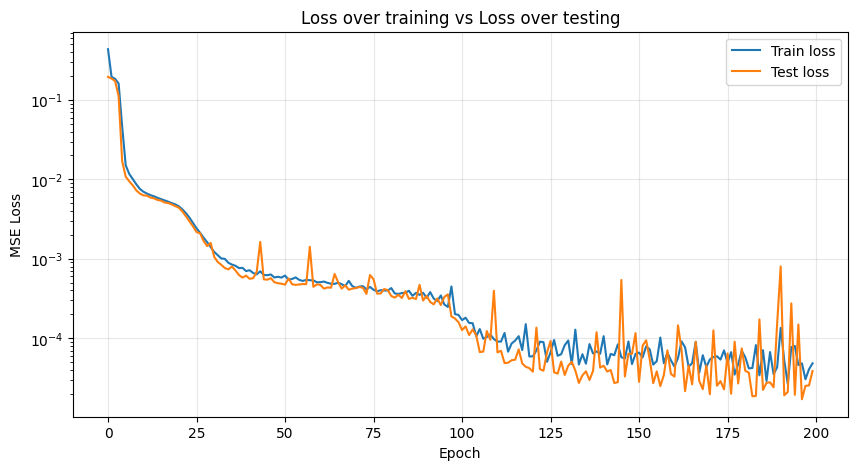

X_train shape: torch.Size([72400, 5])
y_train shape: torch.Size([72400, 1])
y_train min: -0.5165
y_train max: 2.7798
y_train mean: 0.4753
y_train variance: 0.5874

Final train loss: 0.0000
Final test loss: 0.0000


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(test_losses, label='Test loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss over training vs Loss over testing")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_train min: {y_train.min().item():.4f}")
print(f"y_train max: {y_train.max().item():.4f}")
print(f"y_train mean: {y_train.mean().item():.4f}")
print(f"y_train variance: {y_train.var().item():.4f}")
print()
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final test loss: {test_losses[-1]:.4f}")

Printing X_test
tensor([[0.2267, 0.3550, 0.1919, 0.3234, 0.0000],
        [0.2267, 0.3550, 0.1919, 0.3234, 0.0056],
        [0.2267, 0.3550, 0.1919, 0.3234, 0.0111],
        ...,
        [0.0571, 0.2822, 0.9566, 0.0690, 0.9889],
        [0.0571, 0.2822, 0.9566, 0.0690, 0.9944],
        [0.0571, 0.2822, 0.9566, 0.0690, 1.0000]], requires_grad=True)


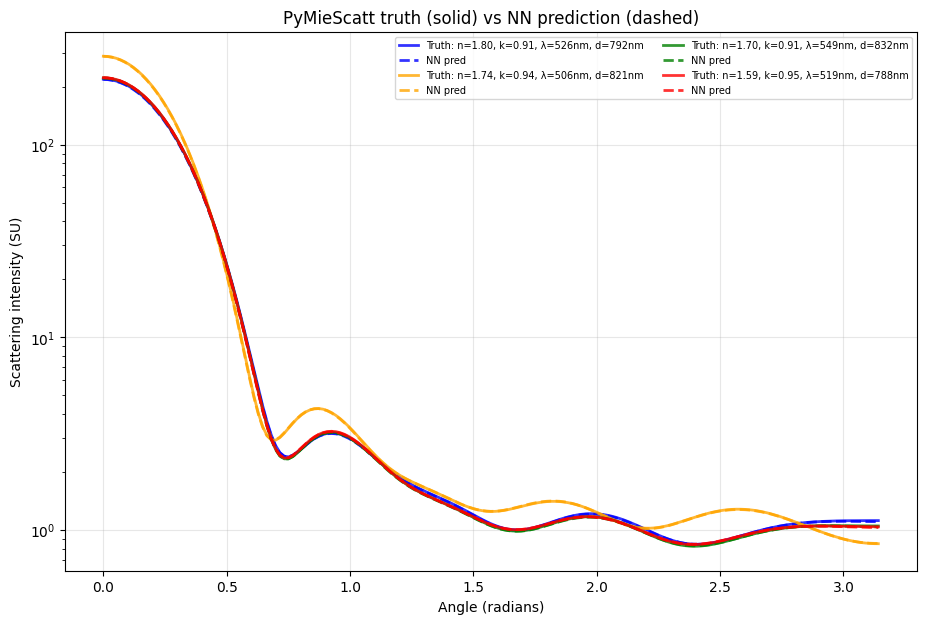

In [ ]:
print("Printing X_test")
print(X_test)

# make predictions using the model
with torch.no_grad():
    test_pred = model(X_test)

# number of test particles
n_test_particles = len(X_test) // 181

plt.figure(figsize=(11, 7))
colors = ['blue', 'orange', 'green', 'red']

#pick 4 random particles
particle_indices = np.random.choice(n_test_particles, 4, replace=False)

# plot particles and their angles
for p_idx, color in zip(particle_indices, colors):

    # determing index boundries
    start = p_idx * 181
    end = start + 181
    
    # numpy wanted a 2D array, convert back into 1D for graphing
    true_log_curve = y_test[start:end].numpy().flatten()
    pred_log_curve = test_pred[start:end].numpy().flatten()
    
    true_curve = 10 ** true_log_curve
    pred_curve = 10 ** pred_log_curve
    
    # Un-normalize particle parameters
    n  = X_test[start, 0].item() * (1.86 - 1.5) + 1.5
    k  = X_test[start, 1].item() * (1.00 - 0.68) + 0.68
    wl = X_test[start, 2].item() * 100 + 450
    d  = X_test[start, 3].item() * 200 + 700

    # Un-normalize angles: stored as 0-1, multiply by π for radians
    angles_rad = X_test[start:end, 4].detach().numpy() * np.pi
    angles_deg = np.degrees(angles_rad)   # for display only
    
    label = f"n={n:.2f}, k={k:.2f}, λ={wl:.0f}nm, d={d:.0f}nm"
    plt.plot(angles_rad, true_curve, '-',  color=color, linewidth=2, alpha=0.8, label=f"Truth: {label}")
    plt.plot(angles_rad, pred_curve, '--', color=color, linewidth=2, alpha=0.8, label="NN pred")

plt.xlabel("Angle (radians)")
plt.ylabel("Scattering intensity (SU)")
plt.title("PyMieScatt truth (solid) vs NN prediction (dashed)")
plt.yscale('log')
plt.legend(fontsize=7, ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

Neural Network Prediction Time
Total time: 0.0017056465s for prediction
PyMieScatt Time
0.04589486122131348 time to compute 180 degrees of a single particle using pyMieScatt
homogeneous particle (on device: cpu)
 - layers   = 1
 - radii    = tensor([450.])nm
 - materials: ['eps=2.61+i3.800']
 - environment    : eps=1.00

Calculating True curve using PyMieDiff
tensor([431.0678, 429.6666, 425.4856, 418.5988, 409.1209, 397.2124, 383.0719,
        366.9324, 349.0538, 329.7182, 309.2247, 287.8788, 265.9890, 243.8577,
        221.7768, 200.0211, 178.8423, 158.4663, 139.0889, 120.8743, 103.9517,
         88.4170,  74.3317,  61.7250,  50.5948,  40.9119,  32.6219,  25.6494,
         19.9017,  15.2729,  11.6478,   8.9059,   6.9250,   5.5842,   4.7675,
          4.3656,   4.2783,   4.4155,   4.6988,   5.0618,   5.4497,   5.8197,
          6.1400,   6.3887,   6.5530,   6.6280,   6.6148,   6.5197,   6.3527,
          6.1263,   5.8542,   5.5505,   5.2287,   4.9012,   4.5790,   4.2710,
          3.98

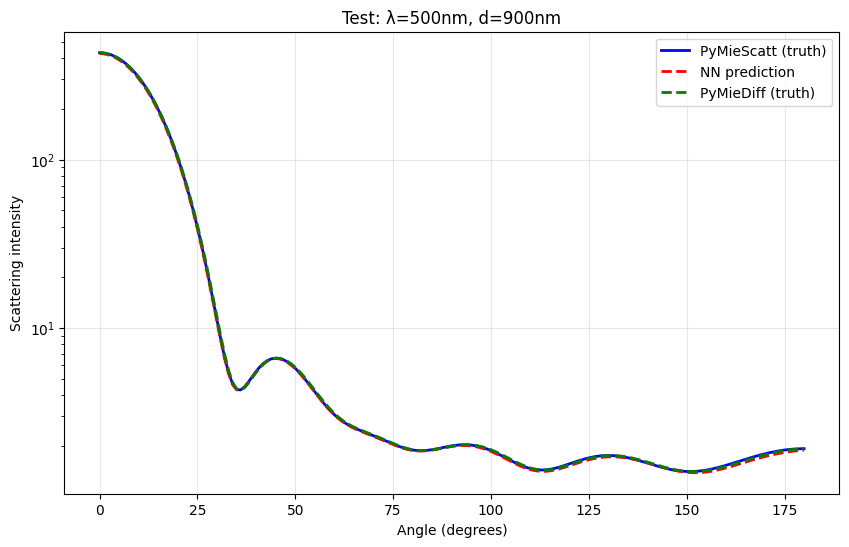

In [ ]:

def predict_scattering(n, k, wavelength, diameter, angle=None):
    if angle is None:
        angle = np.arange(0, 181) * np.pi / 180   # 181 angles in radians
    angle = np.atleast_1d(angle)   # make sure it's an array even if user passes one value
    
    n_query = len(angle)
    raw_inputs = np.zeros((n_query, 5))
    raw_inputs[:, 0] = n
    raw_inputs[:, 1] = k
    raw_inputs[:, 2] = wavelength
    raw_inputs[:, 3] = diameter
    raw_inputs[:, 4] = angle
    
    # Normalize each column
    norm = np.zeros_like(raw_inputs)
    norm[:, 0] = (raw_inputs[:, 0] - 1.5) / 0.36
    norm[:, 1] = (raw_inputs[:, 1] - 0.68) / 0.32
    norm[:, 2] = (raw_inputs[:, 2] - 450) / 100
    norm[:, 3] = (raw_inputs[:, 3] - 700) / 200
    norm[:, 4] = raw_inputs[:, 4] / np.pi # model trained onr radians
    
    input_tensor = torch.FloatTensor(norm)
    
    with torch.no_grad():
        log_pred = model(input_tensor)
    
    return 10 ** log_pred.numpy().flatten()


def true_scattering(wavelength, diameter, n, k):
    """Compute the actual PyMieScatt scattering curve."""
    m = complex(n, k) # for any set of parameters

    calculation_start = time.time()

    theta, SL, SR, SU = ps.ScatteringFunction(
        m, wavelength, diameter,
        minAngle=0, maxAngle=180, angularResolution=1
    )

    calculation_end = time.time()
    elapsed = calculation_end - calculation_start
    print(f"{elapsed} time to compute 180 degrees of a single particle using pyMieScatt")

    return SU

def py_Mie_Diff_Scattering(wavelength, diameter, n, k, environment_value = 1.00):
    # - setup the particle
    wl0 = torch.tensor([wavelength]) # converting into what pyMieDiff requires as input
    k0 = 2 * torch.pi / wl0

    p = pmd.Particle(
        r_layers=[diameter/2],
        mat_layers=[n + k*1j],
        mat_env = 1.00
    )

    theta = torch.arange(0, 181) * torch.pi/181
    print(p)

    print("Calculating True curve using PyMieDiff")
    calculation_start = time.time()
    angle_scattering = p.get_angular_scattering(k0= k0, theta = theta)
    print(angle_scattering["i_unpol"])
    calculation_end = time.time()
    print("Time taken to compute the true curve using PyMieDiff:")
    print(calculation_end - calculation_start)
    return angle_scattering['i_unpol']

# Pick any wavelength and diameter to test
test_wavelength = 500  # nm
test_diameter = 900    # nm
test_n = 1.9
test_k = 1.0

# Get both predictions
# get prediction curve

print("Neural Network Prediction Time")
training_start = time.time()

nn_curve = predict_scattering(test_n, test_k, test_wavelength, test_diameter)

elapsed = time.time() - training_start
print(f"Total time: {elapsed:.10f}s for prediction")

print("PyMieScatt Time")

true_curve = true_scattering(test_wavelength, test_diameter, test_n, test_k)

true_curve_with_pyMieDiff = py_Mie_Diff_Scattering(test_wavelength, test_diameter, test_n, test_k)

# Calculate error
error = np.mean((np.log10(nn_curve) - np.log10(true_curve))**2)
print(f"Mean squared error (in log space): {error:.6e}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(true_curve, '-',  color='blue', linewidth=2, label='PyMieScatt (truth)')
plt.plot(nn_curve,   '--', color='red',  linewidth=2, label='NN prediction')
plt.plot(true_curve_with_pyMieDiff, '--', color= 'green', linewidth= 2, label = 'PyMieDiff (truth)')
plt.xlabel("Angle (degrees)")
plt.ylabel("Scattering intensity")
plt.title(f"Test: λ={test_wavelength}nm, d={test_diameter}nm")
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
N_D_SPANNING_DATA = 200
m = complex(1.6, 1.0) # match the m value the NN was trained on
fixed_lambda = 500 # I will be varying diameter not wavelength

# Log-spaced diameter sweep — wider than training range
d_span = np.logspace(np.log10(400), np.log10(900), N_D_SPANNING_DATA)

print("Computing Brightness for Each Diamaeter with PyMieScatt")
truth = np.zeros((N_D_SPANNING_DATA, 181)) # create array of 181 arrays which have values of 0

# generate the pyMieScatt curve for each diameter value
for i, d in enumerate(d_span):
    theta, SL, SR, SU = ps.ScatteringFunction(
        m, fixed_lambda, d, minAngle=0, maxAngle=180, angularResolution=1
    )

    # add it in it's spot in the array
    truth[i] = SU
    if i % 50 == 0:
        print(f"  {i}/{N_D_SPANNING_DATA}") 
# print(truth)
# === Predictions from NN ===
print("Computing NN sweep...")
nn_pred = np.zeros((N_D_SPANNING_DATA, 181))

for k, d in enumerate(d_span):
    nn_pred[k] = predict_scattering(
        n=1.6,
        k=1.0,
        wavelength=fixed_lambda,
        diameter=d
    )
# print(nn_pred)

print(f"\nDone!")
print(f"Diameter range: {d_span[0]:.0f} to {d_span[-1]:.0f} nm")
print(f"Training was: 700 to 900 nm")


Computing Brightness for Each Diamaeter with PyMieScatt
  0/200
  50/200
  100/200
  150/200
Computing NN sweep...

Done!
Diameter range: 400 to 900 nm
Training was: 700 to 900 nm


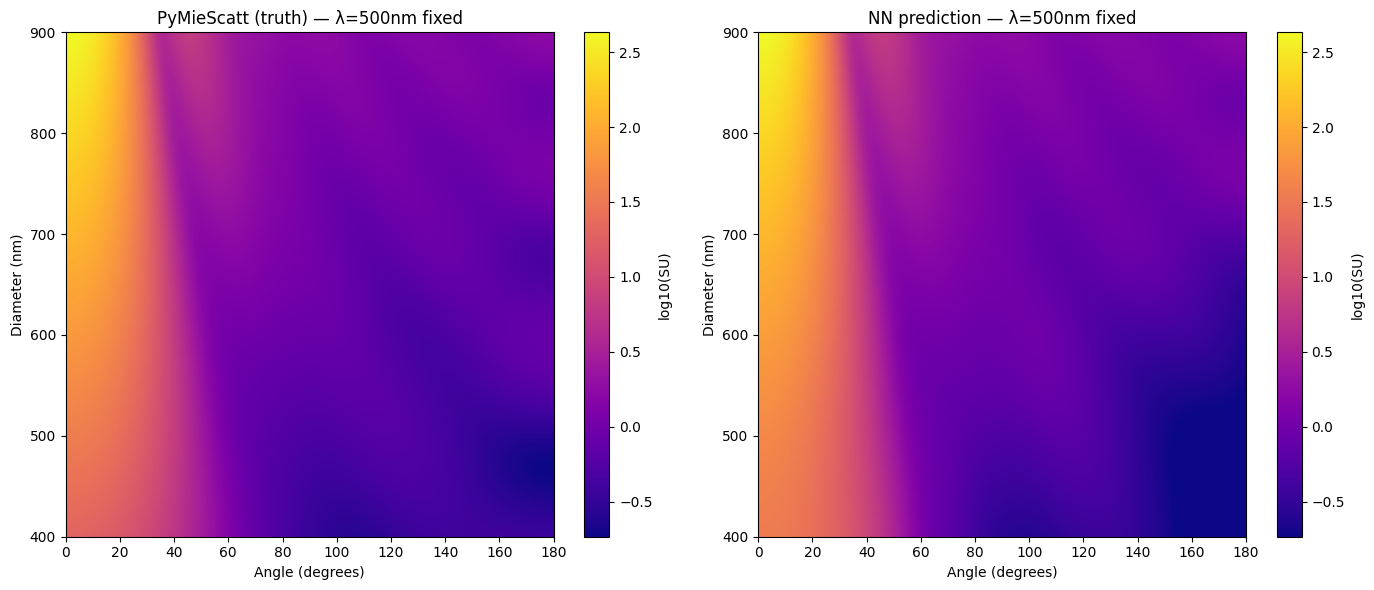

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Use the same color scale across both plots so they're directly comparable
vmin = np.log10(truth).min()
vmax = np.log10(truth).max()

# === PyMieScatt truth ===
im1 = axes[0].imshow(
    np.log10(truth),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[0].set_title(f"PyMieScatt (truth) — λ={fixed_lambda}nm fixed")
axes[0].set_xlabel("Angle (degrees)")
axes[0].set_ylabel("Diameter (nm)")
# Show training range boundaries
plt.colorbar(im1, ax=axes[0], label='log10(SU)')

# === NN prediction ===
im2 = axes[1].imshow(
    np.log10(nn_pred),
    aspect='auto', origin='lower',
    extent=[0, 180, d_span[0], d_span[-1]],
    cmap='plasma', vmin=vmin, vmax=vmax
)
axes[1].set_title(f"NN prediction — λ={fixed_lambda}nm fixed")
axes[1].set_xlabel("Angle (degrees)")
axes[1].set_ylabel("Diameter (nm)")
plt.colorbar(im2, ax=axes[1], label='log10(SU)')

plt.tight_layout()
plt.show()